# Customer Churn and Policy Lapse Modelling

**Domain:** Insurance / Telecommunications  
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Language:** R

---

## Business Problem

Customer retention is a core challenge across insurance, telecommunications, and financial services. In insurance specifically, policy lapse — a customer cancelling or not renewing their policy — directly erodes the premium base and undermines actuarial pricing assumptions. Understanding *who* is likely to lapse and *when* enables targeted retention interventions at the right point in the customer lifecycle.

This project frames churn as a **survival problem** rather than simple binary classification, which is the more realistic formulation: the question is not just *whether* a customer churns but *how long* they stay, and what accelerates or delays departure. Both survival and classification approaches are implemented and compared.

---

**Notebook structure:**
1. Setup
2. Data loading & cleaning
3. Exploratory analysis
4. Kaplan-Meier survival analysis
5. Cox proportional hazards model
6. Accelerated failure time model
7. Classification comparison
8. Results & retention framing

---
*industry_projects - Samantha McGarrigle*

## 1. Setup

In [36]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(survival)
library(broom)
library(gtsummary)
library(ranger)
library(pROC)

select <- dplyr::select

## 2. Data Loading & Cleaning

The IBM Telco dataset contains 7,043 customer records with tenure in months, a binary churn indicator, contract type, service features, and financial variables.

**Data source:** [IBM Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [37]:
telco <- read.csv(file.choose(), stringsAsFactors = FALSE)  # WA_Fn-UseC_-Telco-Customer-Churn.csv
glimpse(telco)

Rows: 7,043
Columns: 21
$ customerID       <chr> "7590-VHVEG", "5575-GNVDE", "3668-QPYBK", "7795-CFOCW…
$ gender           <chr> "Female", "Male", "Male", "Male", "Female", "Female",…
$ SeniorCitizen    <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <chr> "Yes", "No", "No", "No", "No", "No", "No", "No", "Yes…
$ Dependents       <chr> "No", "No", "No", "No", "No", "No", "Yes", "No", "No"…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <chr> "No", "Yes", "Yes", "No", "Yes", "Yes", "Yes", "No", …
$ MultipleLines    <chr> "No phone service", "No", "No", "No phone service", "…
$ InternetService  <chr> "DSL", "DSL", "DSL", "DSL", "Fiber optic", "Fiber opt…
$ OnlineSecurity   <chr> "No", "Yes", "Yes", "Yes", "No", "No", "No", "Yes", "…
$ OnlineBackup     <chr> "Yes", "No", "Yes", "No", "No", "No", "Yes", "No", "N…
$ DeviceProtection <chr> "No", "Yes", "No", "Yes", "No", "Yes", "No", "No", "Y…
$ TechSupport   

In [38]:
# TotalCharges is read as character due to whitespace in a small number of rows
# Convert and inspect missings
telco <- telco %>%
  mutate(
    TotalCharges = as.numeric(TotalCharges),
    churn_event  = ifelse(Churn == "Yes", 1L, 0L),
    SeniorCitizen = factor(SeniorCitizen, levels = c(0, 1),
                           labels = c("No", "Yes")),
    Contract     = factor(Contract,
                          levels = c("Month-to-month", "One year", "Two year")),
    PaymentMethod = factor(PaymentMethod)
  )

cat("Missing TotalCharges:", sum(is.na(telco$TotalCharges)), "\n")
cat("Overall churn rate:  ", round(mean(telco$churn_event) * 100, 1), "%\n")

Missing TotalCharges: 11 
Overall churn rate:   26.5 %


In [39]:
# Drop the 11 rows with missing TotalCharges (new customers with tenure = 0)
telco <- telco %>% filter(!is.na(TotalCharges))

# Construct survival object
surv_obj <- Surv(time = telco$tenure, event = telco$churn_event)

cat("Rows retained:", nrow(telco), "\n")
summary(surv_obj)

Rows retained: 7032 


      time           status      
 Min.   : 1.00   Min.   :0.0000  
 1st Qu.: 9.00   1st Qu.:0.0000  
 Median :29.00   Median :0.0000  
 Mean   :32.42   Mean   :0.2658  
 3rd Qu.:55.00   3rd Qu.:1.0000  
 Max.   :72.00   Max.   :1.0000  

## 3. Exploratory Analysis

In [40]:
# Summary table: churn rate and median tenure by contract type
telco %>%
  group_by(Contract) %>%
  summarise(
    n          = n(),
    churn_rate = round(mean(churn_event) * 100, 1),
    med_tenure = median(tenure)
  )

Contract,n,churn_rate,med_tenure
<fct>,<int>,<dbl>,<dbl>
Month-to-month,3875,42.7,12
One year,1472,11.3,44
Two year,1685,2.8,64


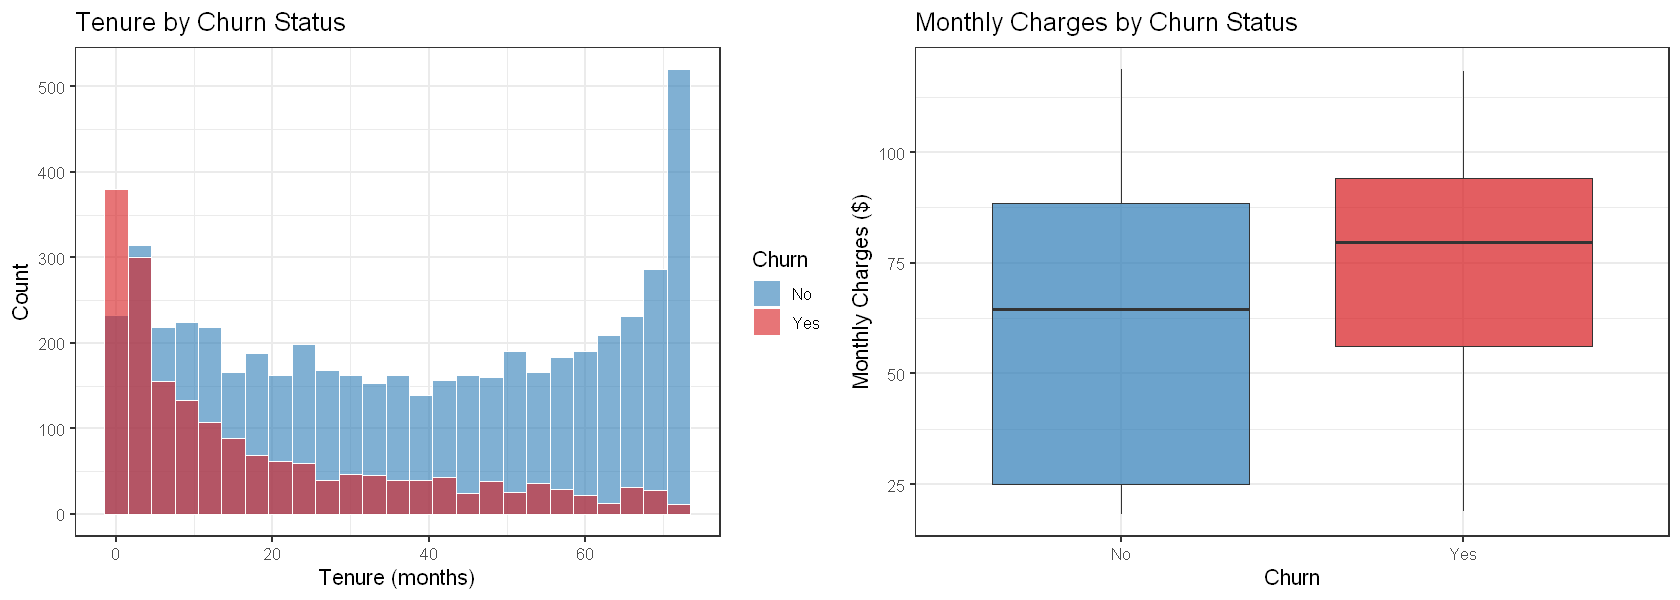

In [41]:
options(repr.plot.width = 14, repr.plot.height = 5)

# Tenure distribution by churn status
p1 <- ggplot(telco, aes(x = tenure, fill = Churn)) +
  geom_histogram(binwidth = 3, position = "identity", alpha = 0.6, color = "white") +
  scale_fill_manual(values = c("No" = "#2C7BB6", "Yes" = "#D7191C")) +
  labs(x = "Tenure (months)", y = "Count", title = "Tenure by Churn Status") +
  theme_bw(base_size = 13)

# Monthly charges by churn status
p2 <- ggplot(telco, aes(x = Churn, y = MonthlyCharges, fill = Churn)) +
  geom_boxplot(alpha = 0.7, outlier.size = 0.8) +
  scale_fill_manual(values = c("No" = "#2C7BB6", "Yes" = "#D7191C")) +
  labs(x = "Churn", y = "Monthly Charges ($)", title = "Monthly Charges by Churn Status") +
  theme_bw(base_size = 13) +
  theme(legend.position = "none")

gridExtra::grid.arrange(p1, p2, ncol = 2)

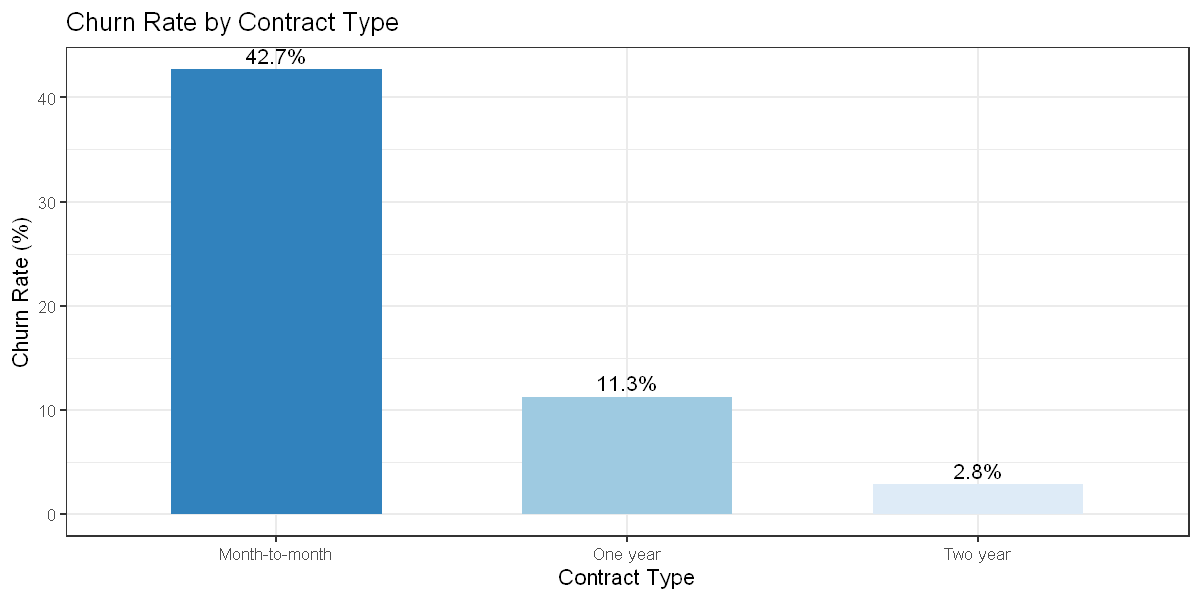

In [42]:
options(repr.plot.width = 10, repr.plot.height = 5)

# Churn rate by contract type
telco %>%
  group_by(Contract) %>%
  summarise(churn_rate = mean(churn_event) * 100) %>%
  ggplot(aes(x = Contract, y = churn_rate, fill = Contract)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = paste0(round(churn_rate, 1), "%")), vjust = -0.4, size = 4.5) +
  scale_fill_brewer(palette = "Blues", direction = -1) +
  labs(x = "Contract Type", y = "Churn Rate (%)", title = "Churn Rate by Contract Type") +
  theme_bw(base_size = 13) +
  theme(legend.position = "none")

## 4. Kaplan-Meier Survival Analysis

KM curves provide a non-parametric estimate of the survival function — here, the probability of a customer still being active at time *t*. Log-rank tests assess whether survival differs significantly between groups.

In [43]:
# KM by contract type
km_contract <- survfit(Surv(tenure, churn_event) ~ Contract, data = telco)
print(km_contract)

# Log-rank test
survdiff(Surv(tenure, churn_event) ~ Contract, data = telco)

Call: survfit(formula = Surv(tenure, churn_event) ~ Contract, data = telco)

                           n events median 0.95LCL 0.95UCL
Contract=Month-to-month 3875   1655     35      32      38
Contract=One year       1472    166     NA      72      NA
Contract=Two year       1685     48     NA      NA      NA


Call:
survdiff(formula = Surv(tenure, churn_event) ~ Contract, data = telco)

                           N Observed Expected (O-E)^2/E (O-E)^2/V
Contract=Month-to-month 3875     1655      708      1265      2304
Contract=One year       1472      166      471       197       270
Contract=Two year       1685       48      690       597      1061

 Chisq= 2353  on 2 degrees of freedom, p= <2e-16 

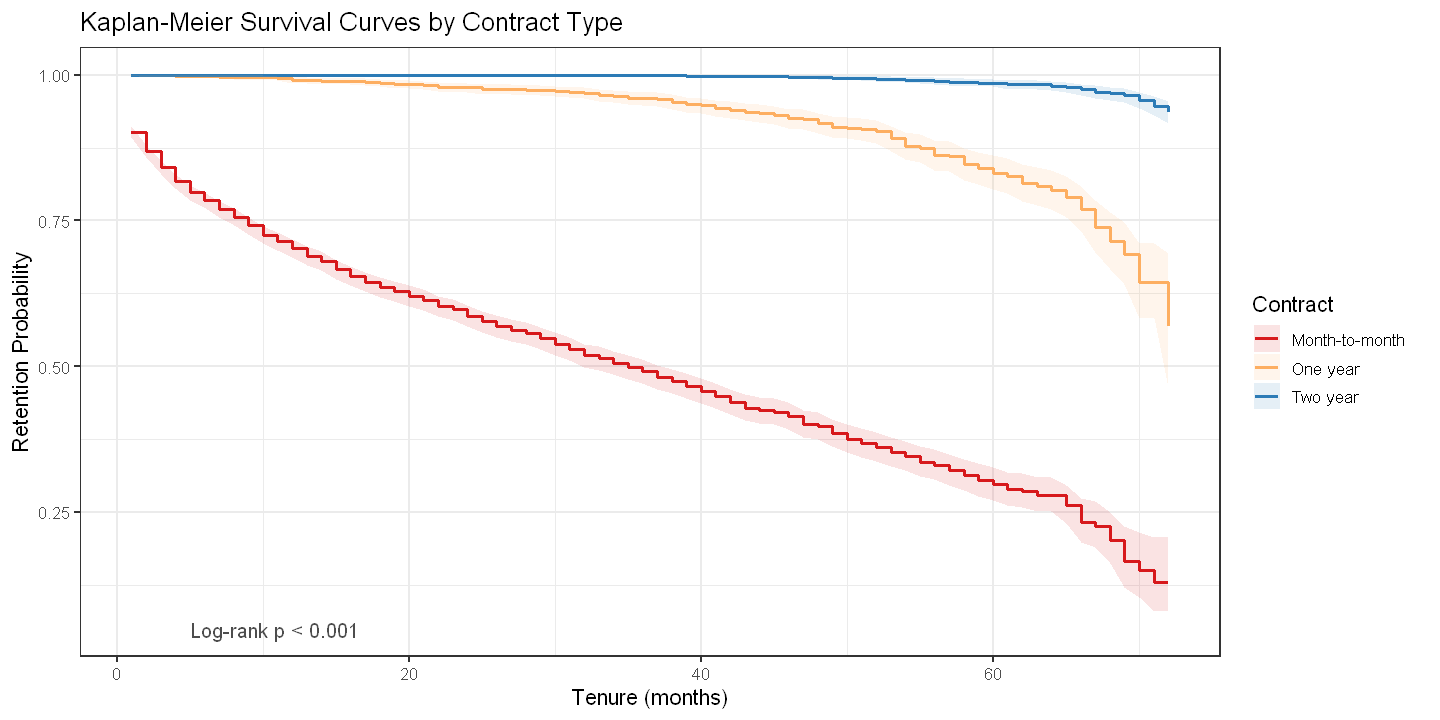

In [44]:
options(repr.plot.width = 12, repr.plot.height = 6)

# Tidy KM fit for ggplot2
km_contract_df <- tidy(km_contract) %>%
  mutate(strata = gsub("Contract=", "", strata),
         strata = factor(strata, levels = c("Month-to-month", "One year", "Two year")))

# Log-rank p-value
lr_p <- survdiff(Surv(tenure, churn_event) ~ Contract, data = telco)
lr_pval <- 1 - pchisq(lr_p$chisq, df = length(lr_p$obs) - 1)
pval_label <- paste0("Log-rank p ", ifelse(lr_pval < 0.001, "< 0.001", paste0("= ", round(lr_pval, 3))))

ggplot(km_contract_df, aes(x = time, y = estimate,
                           color = strata, fill = strata)) +
  geom_step(linewidth = 0.9) +
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.12, color = NA) +
  scale_color_manual(values = c("Month-to-month" = "#D7191C",
                                "One year"        = "#FDAE61",
                                "Two year"        = "#2C7BB6")) +
  scale_fill_manual(values  = c("Month-to-month" = "#D7191C",
                                "One year"        = "#FDAE61",
                                "Two year"        = "#2C7BB6")) +
  annotate("text", x = 5, y = 0.05, label = pval_label,
           hjust = 0, size = 4.2, color = "grey30") +
  labs(x = "Tenure (months)", y = "Retention Probability",
       title = "Kaplan-Meier Survival Curves by Contract Type",
       color = "Contract", fill = "Contract") +
  theme_bw(base_size = 13)

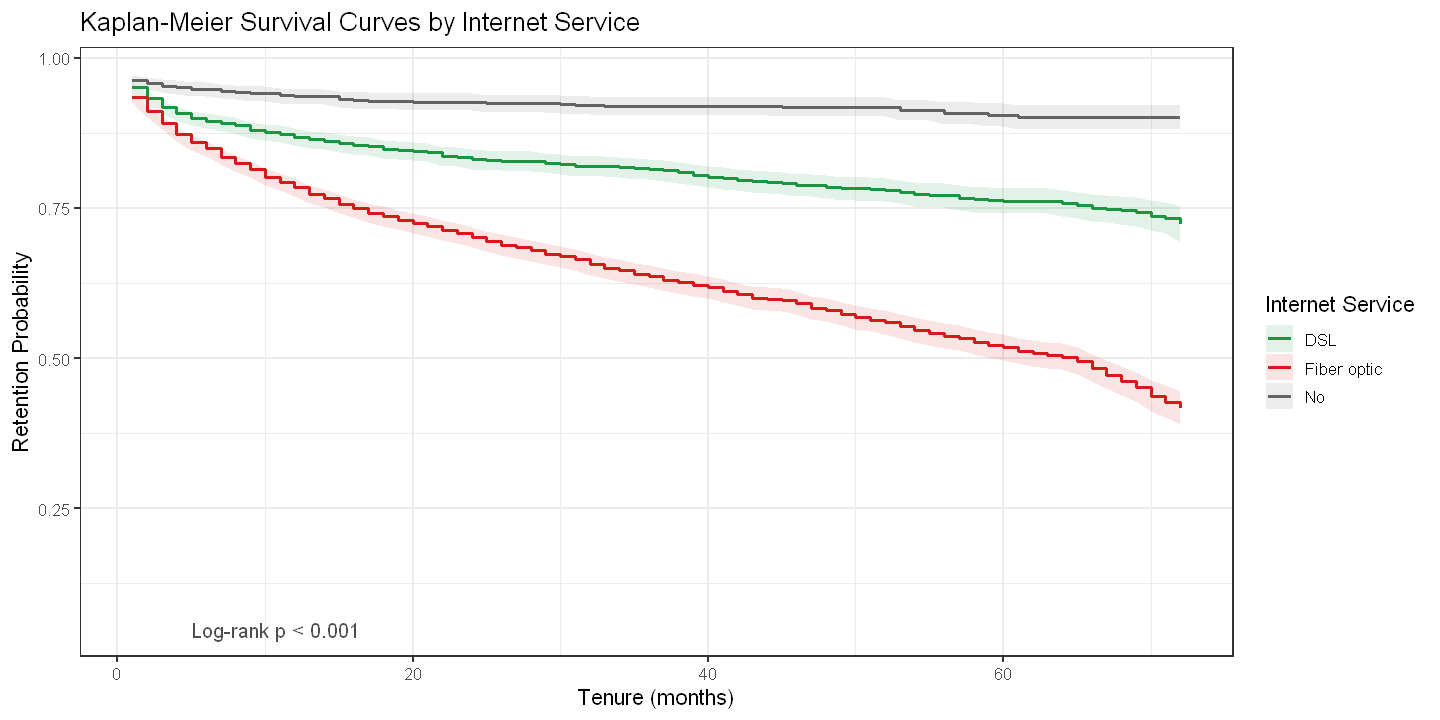

In [45]:
options(repr.plot.width = 12, repr.plot.height = 6)

km_internet    <- survfit(Surv(tenure, churn_event) ~ InternetService, data = telco)
km_internet_df <- tidy(km_internet) %>%
  mutate(strata = gsub("InternetService=", "", strata))

lr_int   <- survdiff(Surv(tenure, churn_event) ~ InternetService, data = telco)
lr_pval2 <- 1 - pchisq(lr_int$chisq, df = length(lr_int$obs) - 1)
pval_label2 <- paste0("Log-rank p ", ifelse(lr_pval2 < 0.001, "< 0.001", paste0("= ", round(lr_pval2, 3))))

ggplot(km_internet_df, aes(x = time, y = estimate,
                           color = strata, fill = strata)) +
  geom_step(linewidth = 0.9) +
  geom_ribbon(aes(ymin = conf.low, ymax = conf.high), alpha = 0.12, color = NA) +
  scale_color_manual(values = c("DSL"         = "#1A9641",
                                "Fiber optic" = "#D7191C",
                                "No"           = "#636363")) +
  scale_fill_manual(values  = c("DSL"         = "#1A9641",
                                "Fiber optic" = "#D7191C",
                                "No"           = "#636363")) +
  annotate("text", x = 5, y = 0.05, label = pval_label2,
           hjust = 0, size = 4.2, color = "grey30") +
  labs(x = "Tenure (months)", y = "Retention Probability",
       title = "Kaplan-Meier Survival Curves by Internet Service",
       color = "Internet Service", fill = "Internet Service") +
  theme_bw(base_size = 13)

## 5. Cox Proportional Hazards Model

The Cox model estimates adjusted hazard ratios for each predictor while making no parametric assumptions about the baseline hazard. HR > 1 indicates increased churn risk; HR < 1 is protective.

The proportional hazards assumption is tested using Schoenfeld residuals.

In [46]:
# Multivariable Cox model
cox_model <- coxph(
  Surv(tenure, churn_event) ~
    Contract + SeniorCitizen + Partner + Dependents +
    InternetService + OnlineSecurity + TechSupport +
    StreamingTV + PaperlessBilling + PaymentMethod +
    MonthlyCharges,
  data = telco
)

summary(cox_model)

Call:
coxph(formula = Surv(tenure, churn_event) ~ Contract + SeniorCitizen + 
    Partner + Dependents + InternetService + OnlineSecurity + 
    TechSupport + StreamingTV + PaperlessBilling + PaymentMethod + 
    MonthlyCharges, data = telco)

  n= 7032, number of events= 1869 

                                          coef exp(coef)  se(coef)       z
ContractOne year                     -1.652748  0.191523  0.087697 -18.846
ContractTwo year                     -3.258553  0.038444  0.164122 -19.854
SeniorCitizenYes                     -0.118907  0.887890  0.056184  -2.116
PartnerYes                           -0.545572  0.579510  0.054920  -9.934
DependentsYes                        -0.059146  0.942569  0.068395  -0.865
InternetServiceFiber optic            1.360335  3.897499  0.127821  10.643
InternetServiceNo                    -1.436970  0.237647  0.127732 -11.250
OnlineSecurityNo internet service           NA        NA  0.000000      NA
OnlineSecurityYes                    -0.50321

                   chisq df       p
Contract          88.979  2 < 2e-16
SeniorCitizen      0.457  1   0.499
Partner           19.664  1 9.2e-06
Dependents         1.386  1   0.239
InternetService   44.330  2 2.4e-10
OnlineSecurity    24.187  1 8.7e-07
TechSupport       42.325  1 7.7e-11
StreamingTV       80.354  1 < 2e-16
PaperlessBilling   3.052  1   0.081
PaymentMethod     46.237  3 5.0e-10
MonthlyCharges   107.976  1 < 2e-16
GLOBAL           275.059 15 < 2e-16


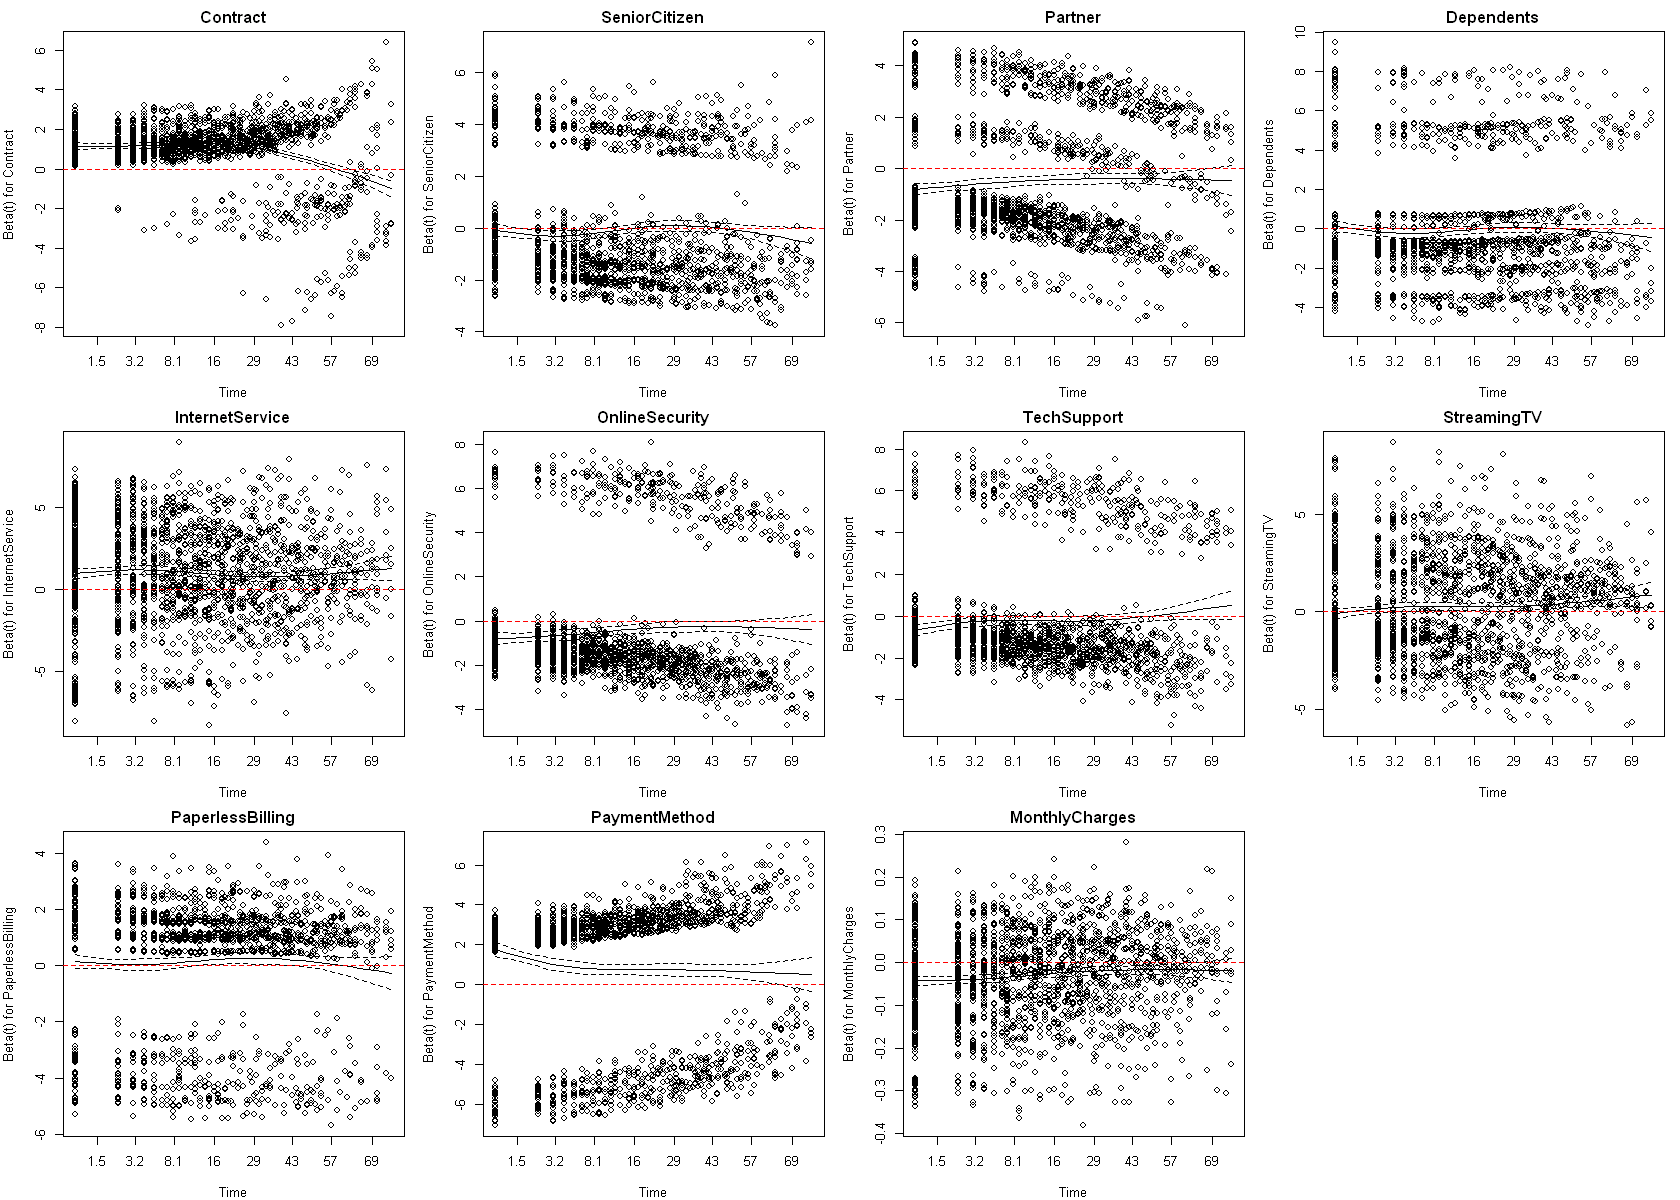

In [47]:
# Test proportional hazards assumption via Schoenfeld residuals
cox_zph <- cox.zph(cox_model)
print(cox_zph)

options(repr.plot.width = 14, repr.plot.height = 10)
# Base R plot for Schoenfeld residuals (no survminer dependency)
par(mfrow = c(3, 4), mar = c(4, 4, 2, 1))
for (i in seq_len(ncol(cox_zph$y))) {
  plot(cox_zph[i], main = colnames(cox_zph$y)[i])
  abline(h = 0, col = "red", lty = 2)
}
par(mfrow = c(1, 1))

Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_errorbarh()`)."
Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`)."


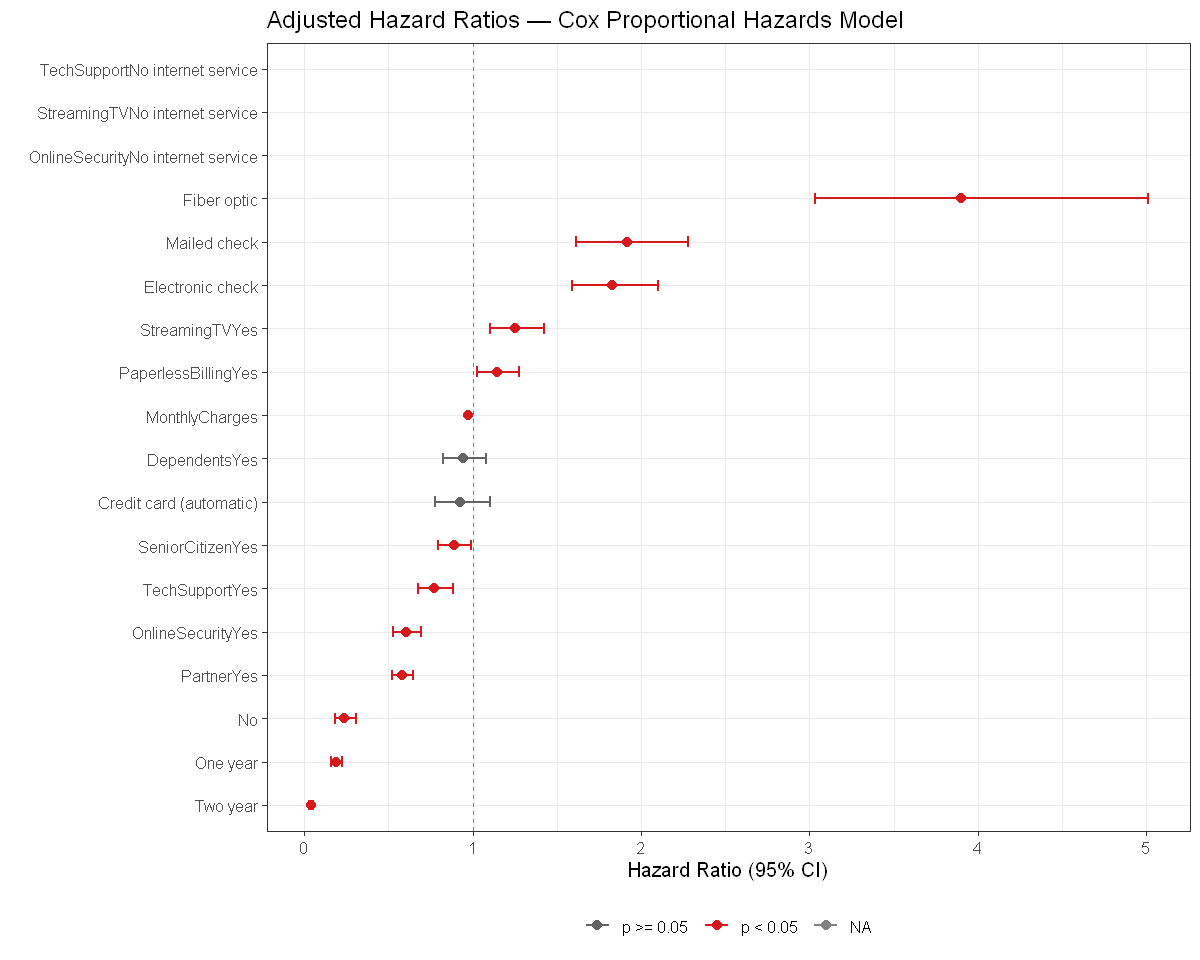

In [48]:
options(repr.plot.width = 10, repr.plot.height = 8)

# Forest plot of hazard ratios using broom::tidy
cox_tidy <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  filter(!grepl("(Intercept)", term)) %>%
  mutate(term = gsub("Contract|PaymentMethod|InternetService", "", term),
         significant = p.value < 0.05)

ggplot(cox_tidy, aes(x = estimate, y = reorder(term, estimate),
                     color = significant)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.25, linewidth = 0.7) +
  geom_point(size = 2.5) +
  scale_color_manual(values = c("TRUE" = "#D7191C", "FALSE" = "#636363"),
                     labels = c("TRUE" = "p < 0.05", "FALSE" = "p >= 0.05")) +
  labs(x = "Hazard Ratio (95% CI)", y = NULL, color = NULL,
       title = "Adjusted Hazard Ratios — Cox Proportional Hazards Model") +
  theme_bw(base_size = 12) +
  theme(legend.position = "bottom")

In [49]:
# Tidy coefficient table with confidence intervals
tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  select(term, estimate, conf.low, conf.high, p.value) %>%
  mutate(across(where(is.numeric), ~ round(., 3))) %>%
  arrange(estimate)

term,estimate,conf.low,conf.high,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ContractTwo year,0.038,0.028,0.053,0.000
ContractOne year,0.192,0.161,0.227,0.000
InternetServiceNo,0.238,0.185,0.305,0.000
PartnerYes,0.580,0.520,0.645,0.000
OnlineSecurityYes,0.605,0.529,0.691,0.000
TechSupportYes,0.771,0.675,0.881,0.000
SeniorCitizenYes,0.888,0.795,0.991,0.034
PaymentMethodCredit card (automatic),0.926,0.775,1.105,0.393
DependentsYes,0.943,0.824,1.078,0.387


## 6. Accelerated Failure Time Model

The Weibull AFT model is a fully parametric alternative to the Cox model. Rather than hazard ratios, it produces **time ratios** — how much longer (or shorter) a customer survives given a unit change in a predictor. This framing can be more intuitive for business communication: "Two-year contract customers stay X times longer than month-to-month customers."

In [50]:
# Weibull AFT model
aft_model <- survreg(
  Surv(tenure, churn_event) ~
    Contract + SeniorCitizen + Partner + Dependents +
    InternetService + OnlineSecurity + TechSupport +
    StreamingTV + PaperlessBilling + PaymentMethod +
    MonthlyCharges,
  data = telco,
  dist = "weibull"
)

summary(aft_model)


Call:
survreg(formula = Surv(tenure, churn_event) ~ Contract + SeniorCitizen + 
    Partner + Dependents + InternetService + OnlineSecurity + 
    TechSupport + StreamingTV + PaperlessBilling + PaymentMethod + 
    MonthlyCharges, data = telco, dist = "weibull")
                                        Value Std. Error      z       p
(Intercept)                           2.49770    0.16360  15.27 < 2e-16
ContractOne year                      1.68977    0.09907  17.06 < 2e-16
ContractTwo year                      3.03204    0.18002  16.84 < 2e-16
SeniorCitizenYes                      0.11591    0.06313   1.84  0.0664
PartnerYes                            0.56541    0.06062   9.33 < 2e-16
DependentsYes                         0.10539    0.07701   1.37  0.1712
InternetServiceFiber optic           -1.46028    0.14315 -10.20 < 2e-16
InternetServiceNo                     1.60415    0.14712  10.90 < 2e-16
OnlineSecurityNo internet service          NA    0.00000     NA      NA
OnlineSecurityYe

In [51]:
# Time ratios: exp(coef) — values > 1 extend survival, < 1 shorten it
tidy(aft_model, conf.int = TRUE) %>%
  mutate(
    time_ratio = round(exp(estimate), 3),
    tr_low     = round(exp(conf.low), 3),
    tr_high    = round(exp(conf.high), 3),
    p.value    = round(p.value, 3)
  ) %>%
  select(term, time_ratio, tr_low, tr_high, p.value) %>%
  arrange(time_ratio)

term,time_ratio,tr_low,tr_high,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
InternetServiceFiber optic,0.232,0.175,0.307,0.000
PaymentMethodMailed check,0.477,0.393,0.578,0.000
PaymentMethodElectronic check,0.513,0.439,0.600,0.000
StreamingTVYes,0.794,0.689,0.915,0.001
PaperlessBillingYes,0.855,0.755,0.969,0.014
MonthlyCharges,1.033,1.026,1.039,0.000
PaymentMethodCredit card (automatic),1.088,0.890,1.328,0.411
DependentsYes,1.111,0.955,1.292,0.171
SeniorCitizenYes,1.123,0.992,1.271,0.066


## 7. Classification Comparison

Logistic regression and random forest are fitted to the binary churn outcome and compared against the Cox model using ROC-AUC. This section illustrates the additional insight the survival framing provides — timing and trajectory — beyond a simple probability of churn.

In [52]:
# Logistic regression
logit_model <- glm(
  churn_event ~
    Contract + SeniorCitizen + Partner + Dependents +
    InternetService + OnlineSecurity + TechSupport +
    StreamingTV + PaperlessBilling + PaymentMethod +
    MonthlyCharges + tenure,
  data   = telco,
  family = binomial
)

telco$logit_pred <- predict(logit_model, type = "response")
roc_logit        <- roc(telco$churn_event, telco$logit_pred, quiet = TRUE)
cat("Logistic regression AUC:", round(auc(roc_logit), 3), "\n")

Logistic regression AUC: 0.844 


In [53]:
# Random forest
rf_vars <- c("Contract", "SeniorCitizen", "Partner", "Dependents",
             "InternetService", "OnlineSecurity", "TechSupport",
             "StreamingTV", "PaperlessBilling", "PaymentMethod",
             "MonthlyCharges", "tenure", "churn_event")

rf_data <- telco %>%
  select(all_of(rf_vars)) %>%
  mutate(churn_event = factor(churn_event))

set.seed(42)
rf_model <- ranger(
  churn_event ~ .,
  data             = rf_data,
  num.trees        = 500,
  probability      = TRUE,
  importance       = "impurity"
)

rf_preds  <- rf_model$predictions[, "1"]
roc_rf    <- roc(telco$churn_event, rf_preds, quiet = TRUE)
cat("Random forest AUC:", round(auc(roc_rf), 3), "\n")

Random forest AUC: 0.838 


In [54]:
# Cox model linear predictor as a discrimination score
telco$cox_lp  <- predict(cox_model, type = "lp")
roc_cox       <- roc(telco$churn_event, telco$cox_lp, quiet = TRUE)
cat("Cox model AUC:", round(auc(roc_cox), 3), "\n")

Cox model AUC: 0.806 


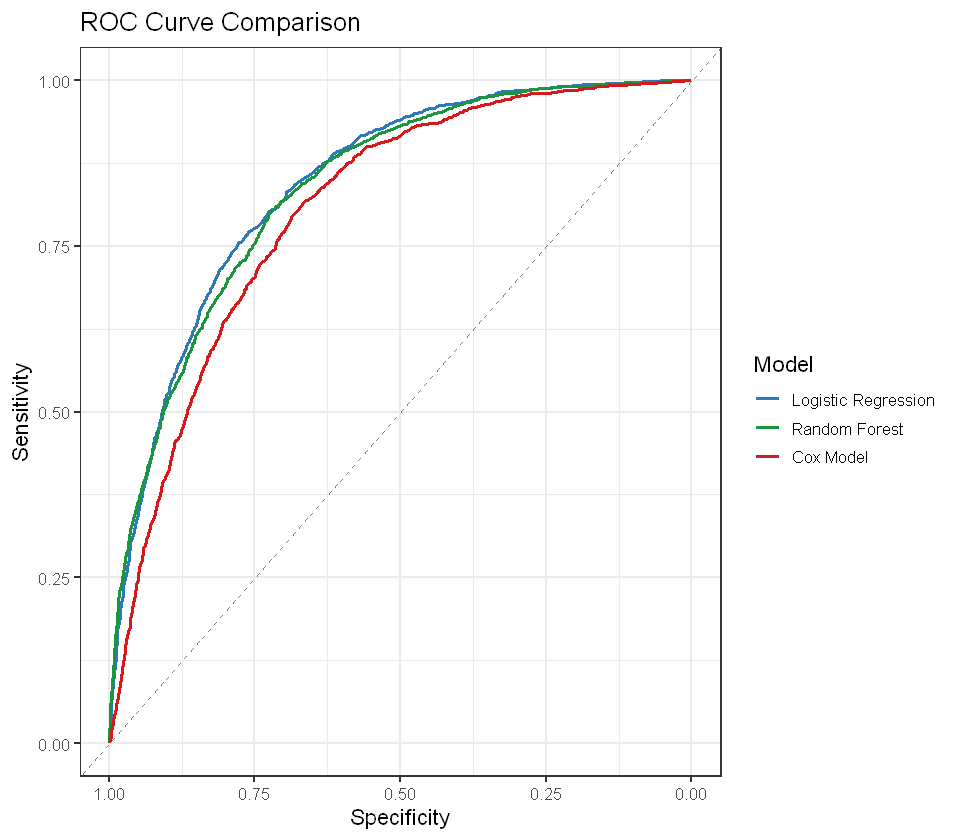

In [55]:
options(repr.plot.width = 8, repr.plot.height = 7)

# ROC curve comparison
ggroc(list(
    "Logistic Regression" = roc_logit,
    "Random Forest"       = roc_rf,
    "Cox Model"           = roc_cox
  ),
  size = 0.9
) +
  geom_abline(slope = 1, intercept = 1, linetype = "dashed", color = "grey50") +
  scale_color_manual(values = c("#2C7BB6", "#1A9641", "#D7191C")) +
  labs(
    title = "ROC Curve Comparison",
    x     = "Specificity",
    y     = "Sensitivity",
    color = "Model"
  ) +
  theme_bw(base_size = 13)

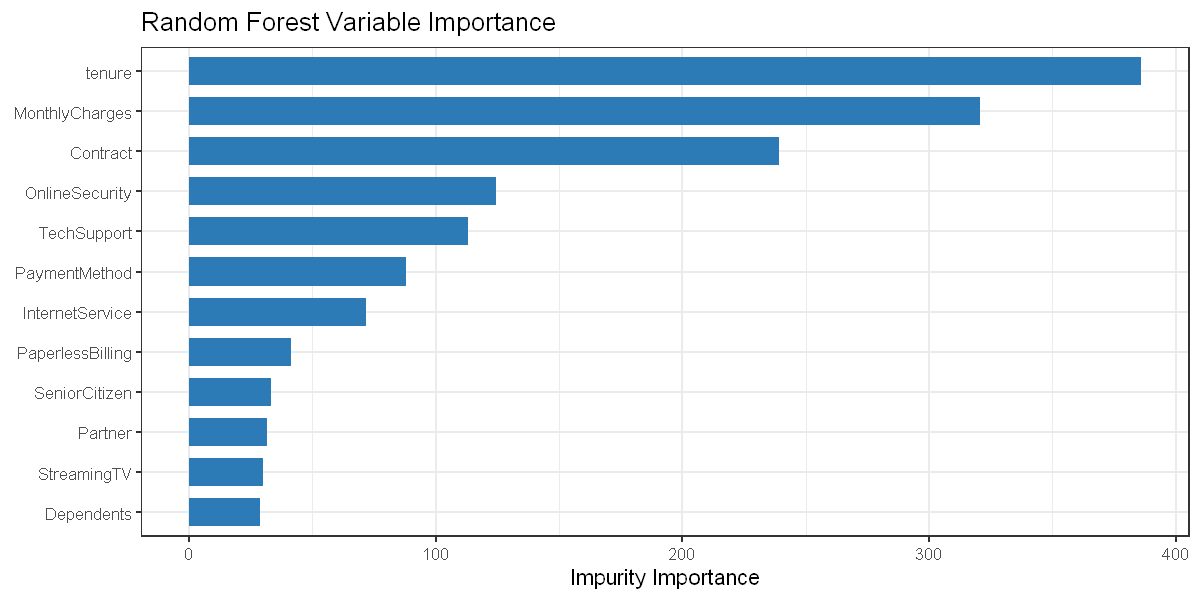

In [56]:
options(repr.plot.width = 10, repr.plot.height = 5)

# Random forest variable importance
importance_df <- data.frame(
  variable   = names(rf_model$variable.importance),
  importance = rf_model$variable.importance
) %>% arrange(desc(importance))

ggplot(importance_df, aes(x = reorder(variable, importance), y = importance)) +
  geom_col(fill = "#2C7BB6", width = 0.7) +
  coord_flip() +
  labs(x = NULL, y = "Impurity Importance",
       title = "Random Forest Variable Importance") +
  theme_bw(base_size = 13)

## 8. Results & Retention Framing

Predicted survival curves illustrate how the model can be used operationally: given a new customer profile, what is their predicted retention trajectory?

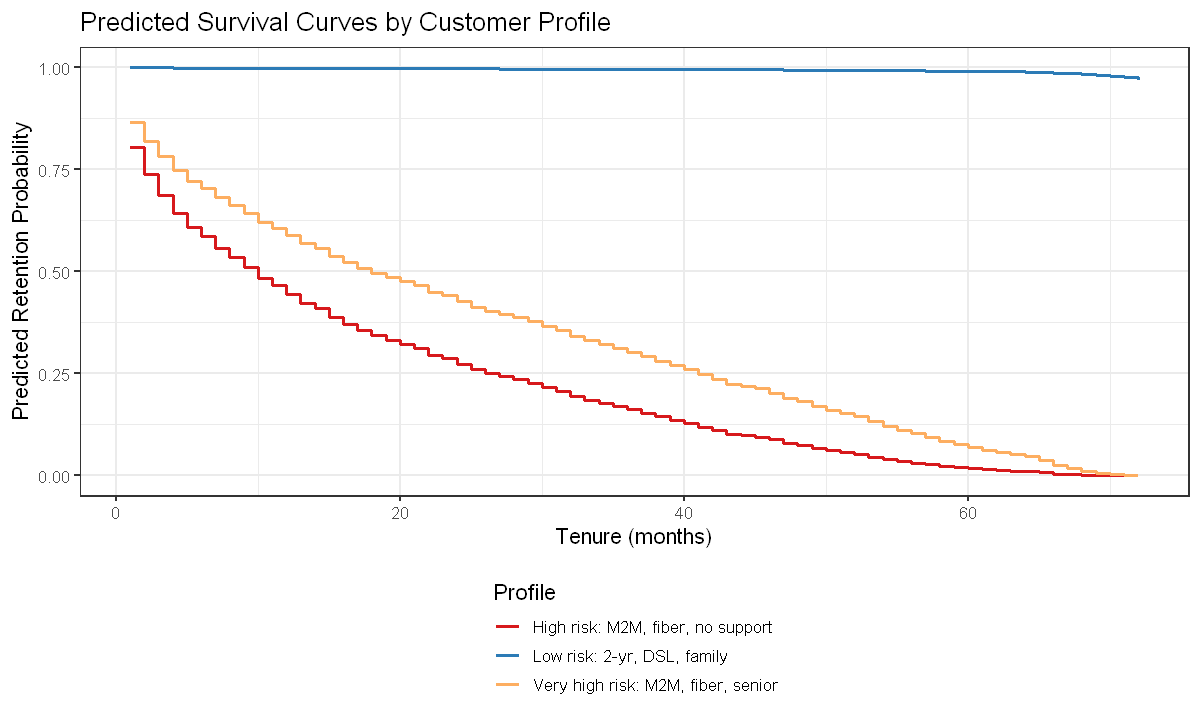

In [57]:
# Predicted survival curves for representative customer profiles
profiles <- data.frame(
  Contract        = factor(c("Month-to-month", "Month-to-month", "Two year"),
                           levels = levels(telco$Contract)),
  SeniorCitizen   = factor(c("No", "Yes", "No"), levels = c("No", "Yes")),
  Partner         = c("No",  "No",  "Yes"),
  Dependents      = c("No",  "No",  "Yes"),
  InternetService = c("Fiber optic", "Fiber optic", "DSL"),
  OnlineSecurity  = c("No",  "No",  "Yes"),
  TechSupport     = c("No",  "No",  "Yes"),
  StreamingTV     = c("Yes", "Yes", "No"),
  PaperlessBilling = c("Yes", "Yes", "No"),
  PaymentMethod   = factor(c("Electronic check", "Electronic check",
                             "Bank transfer (automatic)"),
                           levels = levels(telco$PaymentMethod)),
  MonthlyCharges  = c(85, 95, 55)
)

surv_profiles <- survfit(cox_model, newdata = profiles)

options(repr.plot.width = 10, repr.plot.height = 6)

# survfit(newdata=) returns one survival column per profile;
# reshape from wide (time x profiles) to long manually
profile_labels <- c(
  "Profile 1" = "High risk: M2M, fiber, no support",
  "Profile 2" = "Very high risk: M2M, fiber, senior",
  "Profile 3" = "Low risk: 2-yr, DSL, family"
)

surv_prof_df <- data.frame(
  time    = surv_profiles$time,
  surv_profiles$surv
) %>%
  setNames(c("time", names(profile_labels))) %>%
  pivot_longer(-time, names_to = "profile_key", values_to = "estimate") %>%
  mutate(profile = profile_labels[profile_key])

ggplot(surv_prof_df, aes(x = time, y = estimate, color = profile)) +
  geom_step(linewidth = 0.9) +
  scale_color_manual(values = c(
    "High risk: M2M, fiber, no support"  = "#D7191C",
    "Very high risk: M2M, fiber, senior" = "#FDAE61",
    "Low risk: 2-yr, DSL, family"        = "#2C7BB6"
  )) +
  labs(x = "Tenure (months)", y = "Predicted Retention Probability",
       title = "Predicted Survival Curves by Customer Profile",
       color = "Profile") +
  theme_bw(base_size = 13) +
  theme(legend.position = "bottom",
        legend.direction = "vertical")

In [58]:
# Summary: median survival time by contract type (from KM)
surv_summary <- summary(km_contract)$table
cat("Median time to churn by contract type:\n")
print(surv_summary[, c("records", "events", "median", "0.95LCL", "0.95UCL")])

Median time to churn by contract type:
                        records events median 0.95LCL 0.95UCL
Contract=Month-to-month    3875   1655     35      32      38
Contract=One year          1472    166     NA      72      NA
Contract=Two year          1685     48     NA      NA      NA


### Key findings

**Strongest churn risk factors (Cox HR > 1):**
- Month-to-month contract (vs. two-year): substantially elevated hazard
- Fiber optic internet service: higher hazard than DSL or no internet
- Electronic check payment: higher hazard than automatic payment methods
- No online security or tech support

**Protective factors (Cox HR < 1):**
- Two-year contract: strongest single protective factor
- Having a partner or dependents
- Automatic payment enrollment

**Survival vs. classification:**
- Random forest achieves the highest AUC for binary prediction
- The Cox model provides comparable discrimination with the added benefit of timing: *when* in the customer lifecycle to intervene
- Month-to-month customers face peak churn risk in the first 12 months — this is the primary retention intervention window

**Retention strategy implications:**
- Prioritize contract upgrade offers within the first 6 months for month-to-month customers
- Fiber optic customers with no security/support add-ons are a high-value retention segment
- Automatic payment enrollment is both correlated with retention and actionable at onboarding